# 5주차 강사용 Notebook — 그래프로 공정 상태 이해하기

학생용 Notebook과 동일한 흐름이며, 예상 결과와 설명 포인트를 함께 담았습니다.

## 1단계. 라이브러리 불러오기

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
print('준비 완료')

준비 완료


## 2단계. 데이터 읽기
**설명 포인트**: `pd.to_datetime()`을 쓰지 않으면 `측정시간`이 문자열로 남아 있어,
선 그래프를 시간 순서대로 그릴 수 없다는 점을 강조.

In [2]:
df = pd.read_csv("../../data/weekly/week05/week05_process_visualization.csv")
df["측정시간"] = pd.to_datetime(df["측정시간"])
df.head()

,측정시간,로트번호,설비번호,공정명,온도_섭씨,압력_Pa,두께_nm,진동_mm_s,처리시간_sec,합격여부
0,2024-03-01 05:00:00,LOT-0176,EQ-04,포토,299.1,1002.9,99.64,0.503,126.7,1
1,2024-03-01 15:00:00,LOT-0024,EQ-04,식각,300.6,1014.5,98.69,0.489,118.3,1
2,2024-03-01 16:00:00,LOT-0226,EQ-03,증착,298.4,1026.9,99.62,0.508,115.8,1
3,2024-03-01 21:00:00,LOT-0234,EQ-04,증착,305.9,1012.8,104.76,0.460,123.5,1
4,2024-03-02 00:00:00,LOT-0449,EQ-01,증착,299.9,1021.2,99.52,0.541,131.0,1


## 3단계. 선 그래프 — 시간에 따른 온도 변화
**질문할 내용**: "정렬을 하지 않고 그리면 그래프가 어떻게 될까요?" (지그재그로 나옴을 직접 보여줘도 좋음)

C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49453 (\N{HANGUL SYLLABLE SEOB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50472 (\N{HANGUL SYLLABLE SSI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49884 (\N

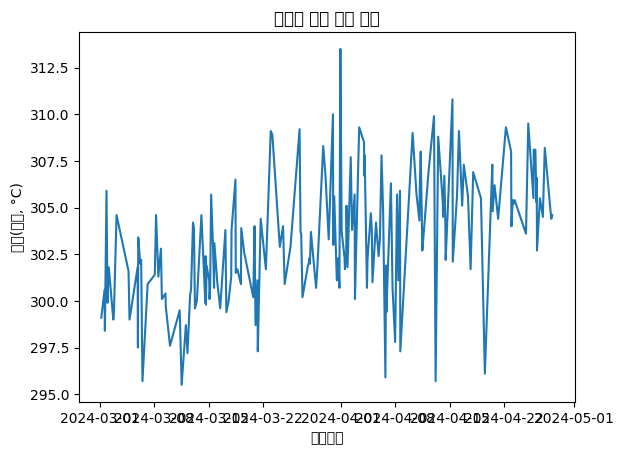

In [3]:
df_sorted = df.sort_values("측정시간")
plt.plot(df_sorted["측정시간"], df_sorted["온도_섭씨"])
plt.title("시간에 따른 온도 변화")
plt.xlabel("측정시간")
plt.ylabel("온도(섭씨, °C)")
plt.show()

**예상 결과**: 3월 초에는 온도가 301℃ 안팎이었다가, 4월로 갈수록 평균이 305℃ 부근까지
서서히 오르는 드리프트가 관찰된다.

## 4단계. 막대그래프 — 설비별 측정 건수
**어려워할 부분**: `value_counts()`에 `.sort_index()`를 안 붙이면 개수 순으로 정렬되어 설비 순서가 뒤섞일 수 있음.

C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49444

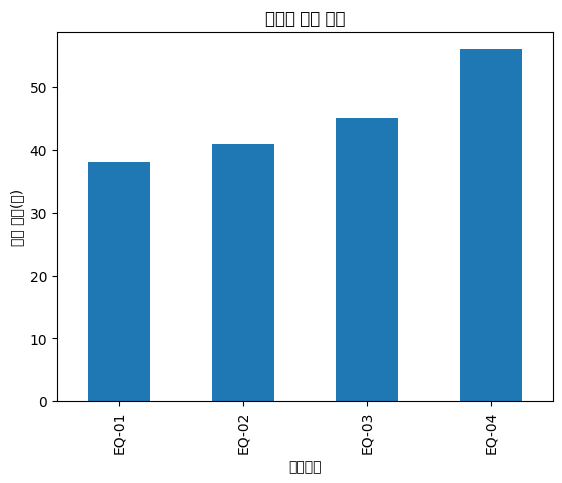

In [4]:
df["설비번호"].value_counts().sort_index().plot(kind="bar")
plt.title("설비별 측정 건수")
plt.xlabel("설비번호")
plt.ylabel("측정 건수(건)")
plt.show()

**예상 결과**: EQ-01 38건, EQ-02 41건, EQ-03 45건, EQ-04 56건 (총 180건).

## 5단계. 히스토그램 — 온도 값의 분포

C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 55176 (\N{H

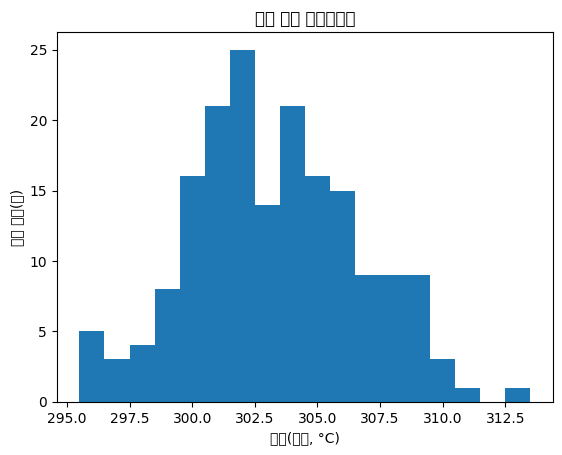

In [5]:
plt.hist(df["온도_섭씨"], bins=18)
plt.title("온도 분포 히스토그램")
plt.xlabel("온도(섭씨, °C)")
plt.ylabel("측정 건수(건)")
plt.show()

**예상 결과**: 평균 약 303.2℃, 표준편차 약 3.4℃로, 정상범위(295~305℃) 근처에 대부분 몰려 있지만 일부는 범위를 벗어난다.

## 6단계. 산점도 — 온도와 두께의 관계

C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46160 (\N{HANGUL SYLLABLE DU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44760 (\N{HANGUL SYLLABLE GGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49328 (\N{HANGUL SYLLABLE SAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


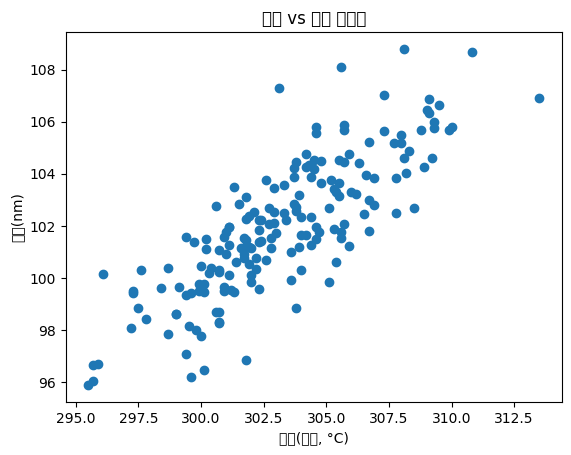

In [6]:
plt.scatter(df["온도_섭씨"], df["두께_nm"])
plt.title("온도 vs 두께 산점도")
plt.xlabel("온도(섭씨, °C)")
plt.ylabel("두께(nm)")
plt.show()

In [7]:
print("상관계수:", round(df["온도_섭씨"].corr(df["두께_nm"]), 3))

상관계수: 0.816


**예상 결과**: 상관계수 약 0.82로 비교적 강한 양의 상관관계. "상관관계 ≠ 원인"이라는 표현을 여기서 처음 소개.

## 7단계. 박스플롯 — 설비별 온도 퍼짐 비교
**설명 포인트**: `by=` 로 그룹을 지정하면 pandas가 자동으로 부제목을 붙이는데, `plt.suptitle("")`로 지워야 깔끔하다.

C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49453 (\N{HANGUL SYLLABLE SEOB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50472 (\N{HANGUL SYLLABLE SSI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49444 (\N{HANGUL SYLLABLE SEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48708 (

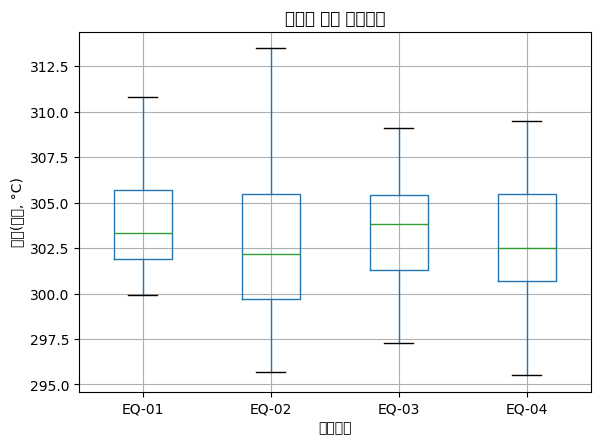

In [8]:
df.boxplot(column="온도_섭씨", by="설비번호")
plt.title("설비별 온도 박스플롯")
plt.suptitle("")
plt.xlabel("설비번호")
plt.ylabel("온도(섭씨, °C)")
plt.show()

In [9]:
print(df.groupby("설비번호")["온도_섭씨"].agg(["mean", "std"]).round(2))

         mean   std
설비번호               
EQ-01  304.07  2.86
EQ-02  302.57  4.29
EQ-03  303.33  2.93
EQ-04  303.05  3.24


**예상 결과**: EQ-02의 표준편차가 약 4.29℃로 가장 크다(다른 설비는 약 2.9~3.2℃). 박스플롯에서도 EQ-02의 상자와 수염이 가장 넓게 퍼져 보인다.

## 8단계. 도전 — 설비별 불합격 비율까지 확인
**실습 시간 조절**: 시간이 부족하면 이 단계는 숙제로 돌려도 된다.

In [10]:
df["불합격"] = df["합격여부"] == -1
print((df.groupby("설비번호")["불합격"].mean() * 100).round(1))

설비번호
EQ-01     5.3
EQ-02    24.4
EQ-03     6.7
EQ-04     3.6
Name: 불합격, dtype: float64


**예상 결과**: EQ-02의 불합격 비율이 약 24.4%로 다른 설비(약 3.6~6.7%)보다 훨씬 높다. 온도 변동이 큰 설비가 불합격도 많다는 결론으로 6주차(groupby 비교)를 예고한다.

## 오류 대처 방법
- 선 그래프가 지그재그로 보임: `sort_values("측정시간")`을 빼먹은 경우.
- x축이 이상하게 보임: `측정시간`을 `pd.to_datetime()`으로 변환하지 않은 경우.
- 박스플롯에 이상한 부제목이 붙음: `plt.suptitle("")`로 지워야 함.